# Cafe Sales — Data Cleaning + EDA

Dataset: `ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training` (Kaggle).
Pipeline: load → audit → clean → save → explore.

Sections:
1. Setup
2. Load raw
3. Audit dirtiness
4. Clean (replace tokens, coerce, derive missing via `Total = Qty × Price`)
5. Save processed
6. EDA — missingness, item revenue/units, time patterns, payment/location, distributions

In [4]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "dirty_cafe_sales.csv"
PROC = ROOT / "data" / "processed" / "clean_cafe_sales.csv"
VIS = ROOT / "visuals"
VIS.mkdir(exist_ok=True)
PROC.parent.mkdir(exist_ok=True)
print("ROOT:", ROOT)

ROOT: /Users/jack2000/Data Analysis/cafe-data-cleaning


## 1. Load raw + first look

In [5]:
df_raw = pd.read_csv(RAW)
print("shape:", df_raw.shape)
df_raw.head(8)

shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28


In [6]:
df_raw.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

## 2. Audit — nulls + dirty tokens (`ERROR`, `UNKNOWN`)

In [7]:
def audit(df):
    nulls = df.isna().sum()
    err = (df.astype(str) == "ERROR").sum()
    unk = (df.astype(str) == "UNKNOWN").sum()
    return pd.DataFrame({"nulls": nulls, "ERROR": err, "UNKNOWN": unk,
                         "dirty_total": nulls + err + unk,
                         "dirty_pct": ((nulls + err + unk) / len(df) * 100).round(2)})

audit_raw = audit(df_raw)
audit_raw

,nulls,ERROR,UNKNOWN,dirty_total,dirty_pct
Transaction ID,0,0,0,0,0.00
Item,333,292,344,969,9.69
Quantity,138,170,171,479,4.79
Price Per Unit,179,190,164,533,5.33
Total Spent,173,164,165,502,5.02
Payment Method,2579,306,293,3178,31.78
Location,3265,358,338,3961,39.61
Transaction Date,159,142,159,460,4.60


In [8]:
print("duplicate Transaction IDs:", df_raw['Transaction ID'].duplicated().sum())
print("date range (raw strings):", sorted(df_raw['Transaction Date'].dropna().unique())[:3], "...",
      sorted(df_raw['Transaction Date'].dropna().unique())[-3:])

duplicate Transaction IDs: 0
date range (raw strings): ['2023-01-01', '2023-01-02', '2023-01-03'] ... ['2023-12-31', 'ERROR', 'UNKNOWN']


**Findings (raw):**
- 10,000 rows, 8 columns. No duplicate transaction IDs.
- Three forms of missing data: literal `NaN`, string `"ERROR"`, string `"UNKNOWN"`.
- Most affected columns: `Location` (~40% dirty), `Payment Method` (~32%), `Item` (~10%).
- Numeric columns store as strings because of `ERROR` / `UNKNOWN` mixed in.
- Date range looks like calendar year 2023.

## 3. Cleaning

**Strategy:**
1. Replace `ERROR` / `UNKNOWN` with `NaN` everywhere.
2. Coerce `Quantity`, `Price Per Unit`, `Total Spent` to numeric. Parse `Transaction Date`.
3. Each menu item has a fixed unit price (verified from clean rows). Use the map to reconstruct missing prices/items.
4. Apply identity `Total = Quantity × Price` to derive any single missing field.
5. Remaining categorical NaN → `"Unknown"` (preserve row, mark gap explicitly).
6. Add derived time fields (year, month, day_of_week).

In [9]:
ITEM_PRICE = {"Coffee": 2.0, "Tea": 1.5, "Sandwich": 4.0, "Salad": 5.0,
              "Cake": 3.0, "Cookie": 1.0, "Juice": 3.0, "Smoothie": 4.0}
PRICE_ITEMS = {}
for it, p in ITEM_PRICE.items():
    PRICE_ITEMS.setdefault(p, []).append(it)
UNIQUE_PRICE_ITEMS = {p: items[0] for p, items in PRICE_ITEMS.items() if len(items) == 1}

print("unique-price items (price -> item):", UNIQUE_PRICE_ITEMS)
print("ambiguous prices:", {p: items for p, items in PRICE_ITEMS.items() if len(items) > 1})

unique-price items (price -> item): {2.0: 'Coffee', 1.5: 'Tea', 5.0: 'Salad', 1.0: 'Cookie'}
ambiguous prices: {4.0: ['Sandwich', 'Smoothie'], 3.0: ['Cake', 'Juice']}


In [10]:
df = df_raw.copy()

# 1. dirty tokens to NaN
df = df.replace({"ERROR": np.nan, "UNKNOWN": np.nan})

# 2. numeric coerce + date parse
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

log = {}

# 3a. price from item
m = df["Item"].notna() & df["Price Per Unit"].isna()
df.loc[m, "Price Per Unit"] = df.loc[m, "Item"].map(ITEM_PRICE)
log["price_filled_from_item"] = int(m.sum())

# 3b. item from price (only when unambiguous)
m = df["Item"].isna() & df["Price Per Unit"].isin(UNIQUE_PRICE_ITEMS)
df.loc[m, "Item"] = df.loc[m, "Price Per Unit"].map(UNIQUE_PRICE_ITEMS)
log["item_filled_from_price"] = int(m.sum())

# 4. derive via Total = Qty * Price
m = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[m, "Total Spent"] = df.loc[m, "Quantity"] * df.loc[m, "Price Per Unit"]
log["total_derived"] = int(m.sum())

m = df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna() & (df["Price Per Unit"] > 0)
df.loc[m, "Quantity"] = (df.loc[m, "Total Spent"] / df.loc[m, "Price Per Unit"]).round()
log["qty_derived"] = int(m.sum())

m = df["Price Per Unit"].isna() & df["Total Spent"].notna() & df["Quantity"].notna() & (df["Quantity"] > 0)
df.loc[m, "Price Per Unit"] = df.loc[m, "Total Spent"] / df.loc[m, "Quantity"]
log["price_derived"] = int(m.sum())

# 5. fill remaining categorical NaN
for col in ["Payment Method", "Location"]:
    log[f"{col}_filled_unknown"] = int(df[col].isna().sum())
    df[col] = df[col].fillna("Unknown")

# 6. dtypes + derived time fields
df["Quantity"] = df["Quantity"].astype("Int64")
df["year"] = df["Transaction Date"].dt.year.astype("Int64")
df["month"] = df["Transaction Date"].dt.month.astype("Int64")
df["day_of_week"] = df["Transaction Date"].dt.day_name()

log

{'price_filled_from_item': 479,
 'item_filled_from_price': 468,
 'total_derived': 479,
 'qty_derived': 456,
 'price_derived': 48,
 'Payment Method_filled_unknown': 3178,
 'Location_filled_unknown': 3961}

**Audit after cleaning:**

In [11]:
audit_clean = pd.DataFrame({
    "before_nulls": df_raw.isna().sum() + (df_raw.astype(str) == "ERROR").sum() + (df_raw.astype(str) == "UNKNOWN").sum(),
    "after_nulls": df.isna().sum().reindex(df_raw.columns)
})
audit_clean["recovered"] = audit_clean["before_nulls"] - audit_clean["after_nulls"]
audit_clean

,before_nulls,after_nulls,recovered
Transaction ID,0,0,0
Item,969,501,468
Quantity,479,23,456
Price Per Unit,533,6,527
Total Spent,502,23,479
Payment Method,3178,0,3178
Location,3961,0,3961
Transaction Date,460,460,0


## 4. Save processed

In [12]:
df.to_csv(PROC, index=False)
print(f"wrote {PROC}  rows={len(df)}  cols={df.shape[1]}")
df.head()

wrote /Users/jack2000/Data Analysis/cafe-data-cleaning/data/processed/clean_cafe_sales.csv  rows=10000  cols=11


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,year,month,day_of_week
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,Friday
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,2023,5,Tuesday
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,Wednesday
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,Thursday
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,Sunday


## 5. EDA

### 5.1 Residual missingness

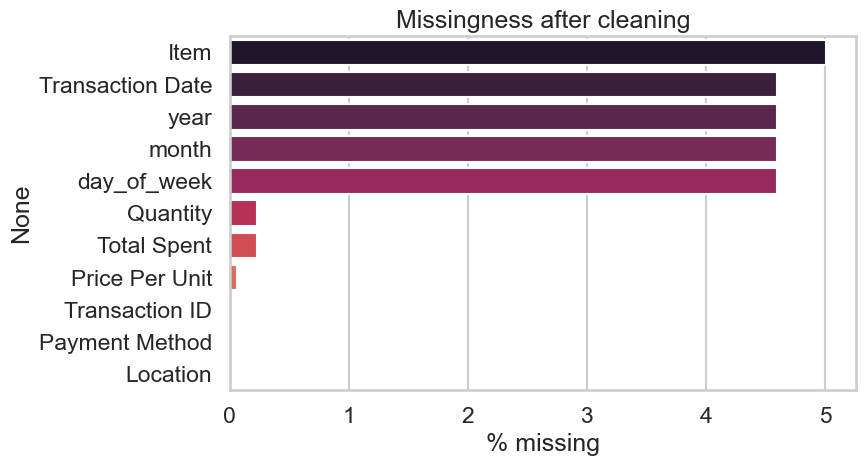

In [13]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=miss.values, y=miss.index, ax=ax, hue=miss.index, palette="rocket", legend=False)
ax.set_xlabel("% missing")
ax.set_title("Missingness after cleaning")
fig.tight_layout()
fig.savefig(VIS / "missingness_after_clean.png", dpi=120)
plt.show()

### 5.2 Revenue + units by item

In [14]:
rev = df.dropna(subset=["Item", "Total Spent", "Quantity"]).copy()
by_item = rev.groupby("Item").agg(revenue=("Total Spent","sum"),
                                  units=("Quantity","sum"),
                                  tx=("Transaction ID","count")).sort_values("revenue", ascending=False)
by_item

,revenue,units,tx
Item,,,
Salad,19075.0,3815,1268
Sandwich,13716.0,3429,1127
Smoothie,13344.0,3336,1094
Juice,10515.0,3505,1168
Cake,10404.0,3468,1138
Coffee,7756.0,3878,1279
Tea,5433.0,3622,1198
Cookie,3585.0,3585,1207


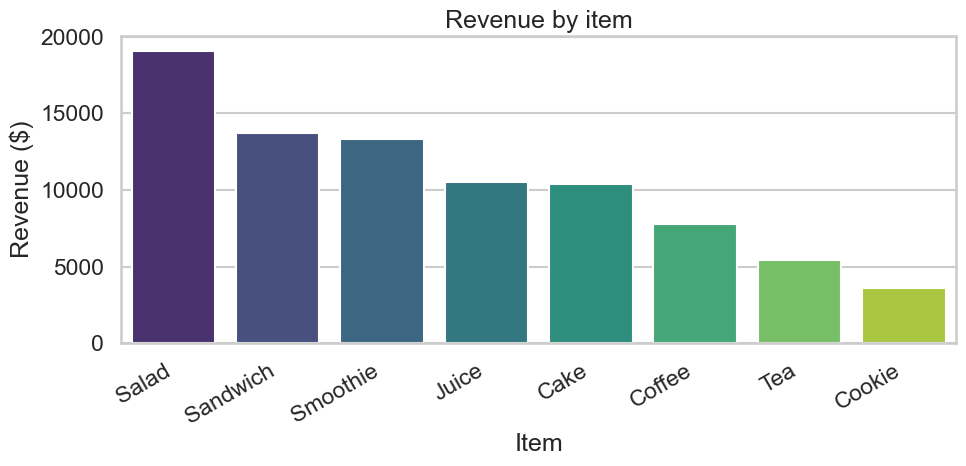

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=by_item.index, y=by_item["revenue"], hue=by_item.index, palette="viridis", ax=ax, legend=False)
ax.set_ylabel("Revenue ($)"); ax.set_title("Revenue by item")
plt.xticks(rotation=30, ha="right"); fig.tight_layout()
fig.savefig(VIS / "revenue_by_item.png", dpi=120); plt.show()

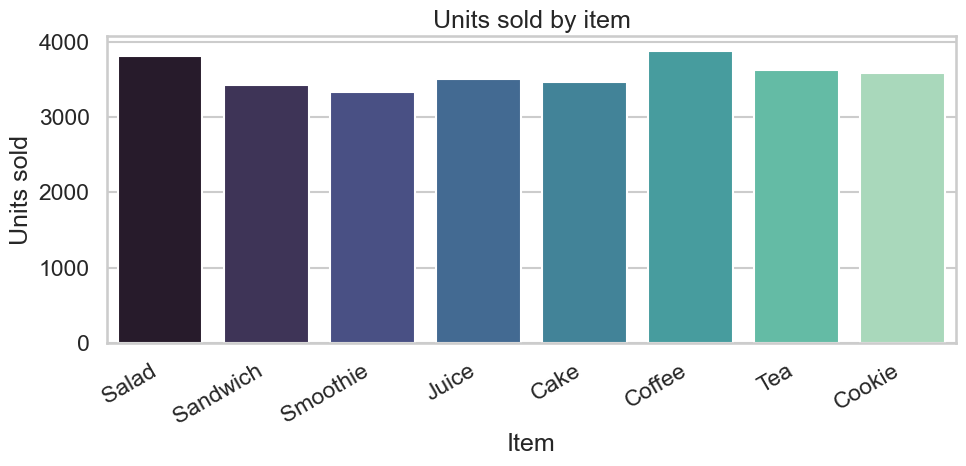

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=by_item.index, y=by_item["units"], hue=by_item.index, palette="mako", ax=ax, legend=False)
ax.set_ylabel("Units sold"); ax.set_title("Units sold by item")
plt.xticks(rotation=30, ha="right"); fig.tight_layout()
fig.savefig(VIS / "units_by_item.png", dpi=120); plt.show()

### 5.3 Monthly revenue trend

Transaction Date
2023-01-01    6918.0
2023-02-01    6172.0
2023-03-01    6899.0
2023-04-01    6743.0
2023-05-01    6482.5
2023-06-01    6863.0
2023-07-01    6535.5
2023-08-01    6589.5
2023-09-01    6429.0
2023-10-01    7040.0
2023-11-01    6636.0
2023-12-01    6613.0
Freq: MS, Name: Total Spent, dtype: float64


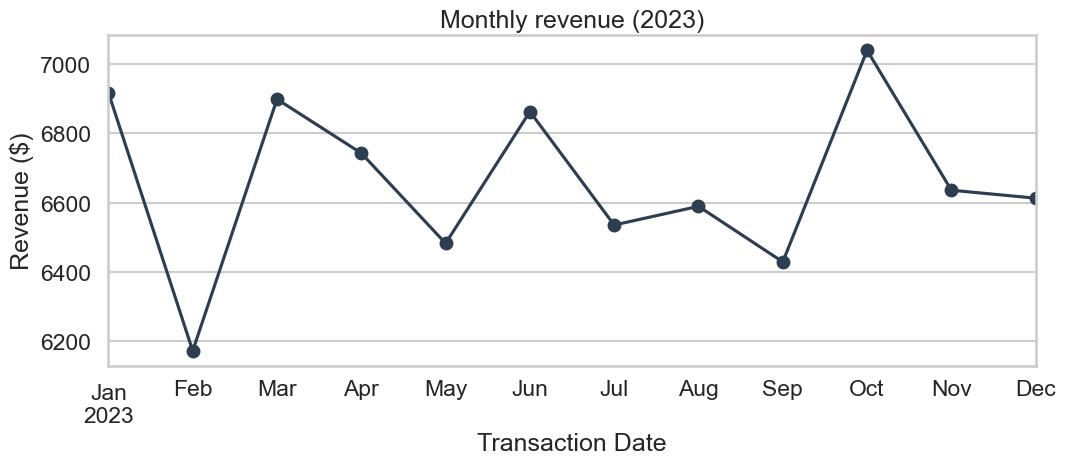

In [17]:
rev_dt = rev.dropna(subset=["Transaction Date"])
monthly = rev_dt.groupby(rev_dt["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
monthly.index = monthly.index.to_timestamp()
print(monthly)

fig, ax = plt.subplots(figsize=(11, 5))
monthly.plot(ax=ax, marker="o", color="#2c3e50")
ax.set_ylabel("Revenue ($)"); ax.set_title("Monthly revenue (2023)")
fig.tight_layout(); fig.savefig(VIS / "monthly_revenue.png", dpi=120); plt.show()

### 5.4 Day-of-week pattern

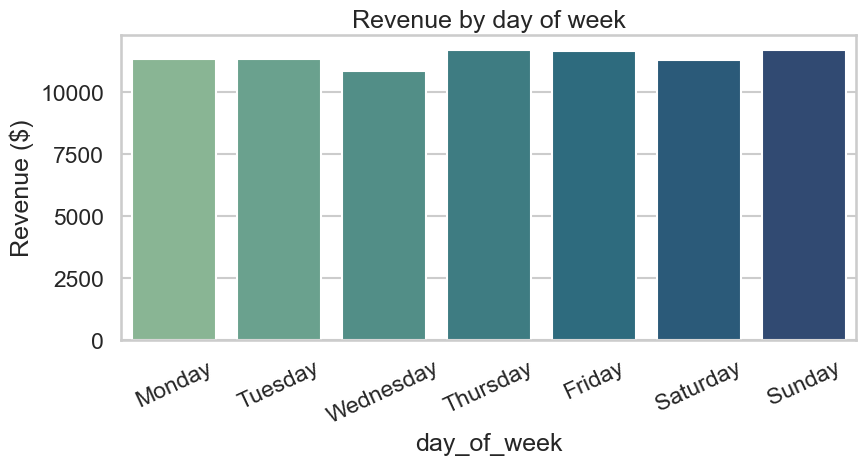

In [18]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = rev_dt.groupby("day_of_week")["Total Spent"].sum().reindex(order)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=dow.index, y=dow.values, hue=dow.index, palette="crest", ax=ax, legend=False)
ax.set_ylabel("Revenue ($)"); ax.set_title("Revenue by day of week")
plt.xticks(rotation=25); fig.tight_layout()
fig.savefig(VIS / "revenue_by_dow.png", dpi=120); plt.show()

### 5.5 Payment method + location mix

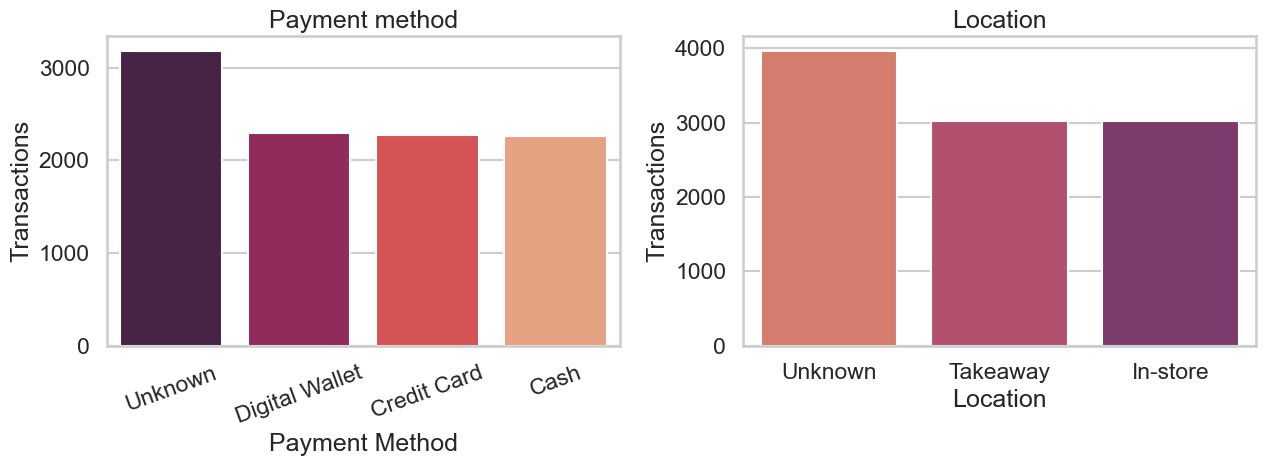

Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64 

 Location
Unknown     3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64


In [19]:
pay = df["Payment Method"].value_counts()
loc = df["Location"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=pay.index, y=pay.values, hue=pay.index, palette="rocket", ax=axes[0], legend=False)
axes[0].set_title("Payment method"); axes[0].set_ylabel("Transactions")
axes[0].tick_params(axis='x', rotation=20)
sns.barplot(x=loc.index, y=loc.values, hue=loc.index, palette="flare", ax=axes[1], legend=False)
axes[1].set_title("Location"); axes[1].set_ylabel("Transactions")
fig.tight_layout()
fig.savefig(VIS / "payment_location_mix.png", dpi=120); plt.show()
print(pay, "\n\n", loc)

### 5.6 Distributions

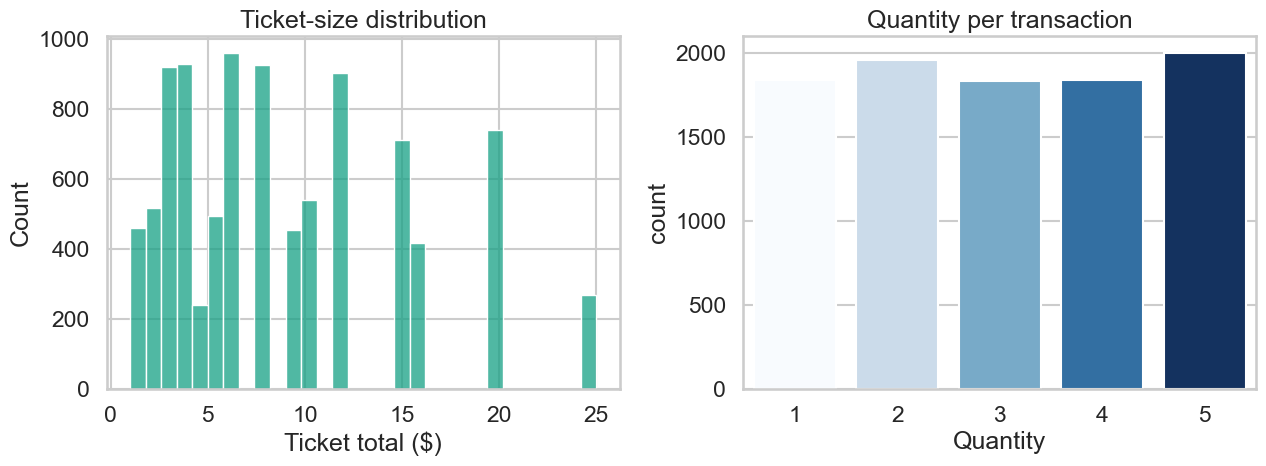

count    9479.000000
mean        8.843549
std         6.031691
min         1.000000
25%         4.000000
50%         7.500000
75%        12.000000
max        25.000000
Name: Total Spent, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(rev["Total Spent"], bins=30, color="#16a085", ax=axes[0])
axes[0].set_title("Ticket-size distribution"); axes[0].set_xlabel("Ticket total ($)")
sns.countplot(x=rev["Quantity"].astype(int), hue=rev["Quantity"].astype(int),
              palette="Blues", ax=axes[1], legend=False)
axes[1].set_title("Quantity per transaction")
fig.tight_layout(); fig.savefig(VIS / "ticket_quantity_dist.png", dpi=120); plt.show()
print(rev["Total Spent"].describe())

## 6. Summary

- **Cleaning recovered ~1.4k field-level gaps** by combining the item-price map with the `Total = Qty × Price` identity.
- **Residual NaN** concentrates in `Item` (n=501) and `Transaction Date` (n=460) — neither can be safely imputed without external data.
- **Revenue mix:** Salad leads ($19k); Coffee leads on units (3.9k) but trails on revenue due to low unit price.
- **Time patterns:** monthly revenue holds steady ~$6.5k–$7k across 2023; no seasonality. Day-of-week revenue near-uniform.
- **Segmentation limits:** Payment Method and Location have ~32–40% `Unknown` even after cleaning — segment splits are noisy.

In [23]:
print(df.info())
print(df.describe(include='all'))
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              9499 non-null   str           
 2   Quantity          9977 non-null   Int64         
 3   Price Per Unit    9994 non-null   float64       
 4   Total Spent       9977 non-null   float64       
 5   Payment Method    10000 non-null  str           
 6   Location          10000 non-null  str           
 7   Transaction Date  9540 non-null   datetime64[us]
 8   year              9540 non-null   Int64         
 9   month             9540 non-null   Int64         
 10  day_of_week       9540 non-null   str           
dtypes: Int64(3), datetime64[us](1), float64(2), str(5)
memory usage: 888.8 KB
None
       Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
count           10000    9499    9977.0     9